## **LoadData From kaggle**

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"akashkumar2235","key":"2feedc82139b0adfce98fc4e2937bcee"}'}

In [5]:
!mkdir -p ~/.kaggle

# ✅ Explanation

🔸 mkdir  
= make directory (folder)

🔸 -p  
= create folder if it doesn’t exist  
(also avoids error if already exists)

🔸 ~/.kaggle  

~ = home directory  
.kaggle = hidden folder (used by Kaggle)

🎯 Meaning:

👉 Create a hidden folder `.kaggle` inside your system  

👉 Also ensures the folder is created safely (no error if it already exists)

In [6]:
!cp kaggle.json ~/.kaggle/

# ✅ Explanation

🔸 cp  
= copy file  

🔸 kaggle.json  
= your API key file (downloaded from Kaggle)  

🔸 ~/.kaggle/  
= destination folder  

🎯 Meaning:

👉 Copy your API key file into Kaggle folder  

👉 So Kaggle can access your credentials  

In [7]:
!chmod 600 ~/.kaggle/kaggle.json

# ✅ Explanation

🔸 chmod  
= change file permissions  

🔸 600  

Means:  

Owner → read + write ✅  
Others → no permission ❌  

🎯 Why important?  

👉 Kaggle requires secure permission  
👉 Otherwise you get error like:  

In [ ]:
#!/bin/bash
!kaggle datasets download abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
 95% 1.93G/2.04G [00:14<00:00, 139MB/s]

In [ ]:
!unzip /content/plantvillage-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e345153-aed9-4879-a2cc-24f9dc5100e7___UF.GRC_YLCV_Lab 01798_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e6938d9-1ab0-4728-993c-1069b66ce73b___UF.GRC_YLCV_Lab 02727_final_mas

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/plantvillage dataset/color",
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(299,299),
    batch_size=32
)


Found 54305 files belonging to 38 classes.
Using 43444 files for training.


In [ ]:
val_ds=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/plantvillage dataset/color",
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(299,299),
    batch_size=32
)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


| 🔢 Step | ⚙️ Parameter                     | 📌 Meaning (Simple)            | 🎯 Why Used                |
| ------- | -------------------------------- | ------------------------------ | -------------------------- |
| 1       | `image_dataset_from_directory()` | Folder से images load करता है  | Dataset create करने के लिए |
| 2       | `"plantvillage dataset/color"`   | Dataset path                   | Images का location         |
| 3       | `validation_split=0.2`           | 20% data validation के लिए     | Model performance check    |
| 4       | `subset="training"`              | Training data select करता है   | Model train करने के लिए    |
| 5       | `subset="validation"`            | Validation data select करता है | Accuracy check करने के लिए |
| 6       | `seed=42`                        | Same random split हर बार       | Consistency (important)    |
| 7       | `image_size=(299,299)`           | Images resize होती हैं         | InceptionV3 requirement    |
| 8       | `batch_size=32`                  | 32 images एक साथ               | Faster training            |


In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [ ]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.2),
])

## **LoadPretrained model**

In [ ]:
base_model=tf.keras.applications.InceptionV3(
    weights='imagenet',
    input_shape=(299,299,3),
    include_top=False
)

In [2]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
base_model.trainable=False

In [ ]:
base_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 149, 149,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 147, 147,  │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 147, 147,  │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 73, 73,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 73, 73,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 71, 71,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_192[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

inputs = tf.keras.Input(shape=(299, 299, 3))

# Augmentation apply
x = data_augmentation(inputs)

# Preprocessing apply
x = preprocess_input(x)

# Base model
x = base_model(x, training=False)

# Head
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(38, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

| Step | Layer               | Work              | Why Important          |
| ---- | ------------------- | ----------------- | ---------------------- |
| 1    | `base_model.output` | Features लेना     | Pre-trained knowledge  |
| 2    | GlobalAvgPool       | Data compress     | Reduce parameters      |
| 3    | Dense(128)          | Learning          | Pattern detection      |
| 4    | Dropout(0.5)        | Overfitting रोकना | Better accuracy        |
| 5    | Dense(38, softmax)  | Final output      | Multi-class prediction |
| 6    | Model()             | Full model बनाना  | Training ready         |


## **Compile time**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

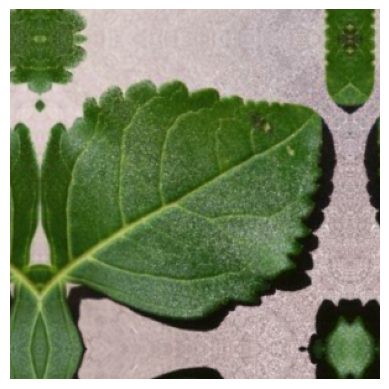

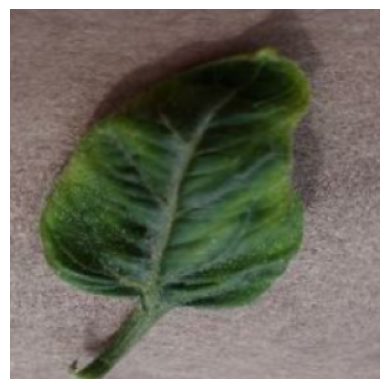

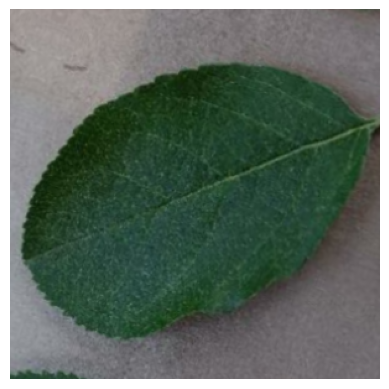

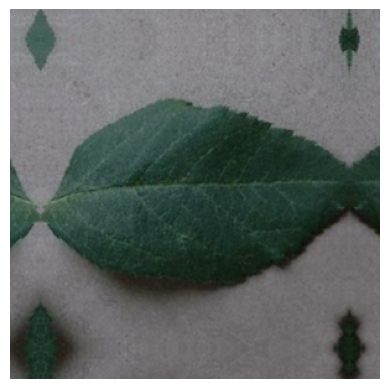

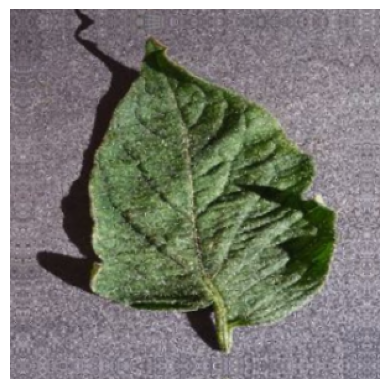

In [ ]:
import matplotlib.pyplot as plt

for images, _ in train_ds.take(1):
    augmented = data_augmentation(images)

    for i in range(5):
        img = augmented[i]
        img = (img + 1) / 2   # fix

        plt.imshow(img.numpy())
        plt.axis("off")
        plt.show()

## **Train Time**

“I trained an Inception v3 model on 54K+ images across 38 classes using TensorFlow with transfer learning.”

🔥 Ye line = selection level 💯**

In [1]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

NameError: name 'tf' is not defined

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 287s 203ms/step - accuracy: 0.2648 - loss: 2.7077 - val_accuracy: 0.3738 - val_loss: 2.2263
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 271s 200ms/step - accuracy: 0.3480 - loss: 2.3139 - val_accuracy: 0.4351 - val_loss: 1.9436
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 272s 200ms/step - accuracy: 0.3786 - loss: 2.1698 - val_accuracy: 0.4616 - val_loss: 1.8245
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 272s 200ms/step - accuracy: 0.3963 - loss: 2.0910 - val_accuracy: 0.4566 - val_loss: 1.7937
Epoch 5/10
 855/1358 ━━━━━━━━━━━━━━━━━━━━ 1:21 162ms/step - accuracy: 0.4041 - loss: 2.0504